# 03. The price model

*Rent Reality Check - London. Created by **Kevin Steepan**.*

---

## Where we are

Notebook 01 set the target (`log(price)`) and the score to beat (a lookup table at
**£-MAE ≈ 90 / R² ≈ 0.49**). Notebook 02 showed that *exact* location adds signal
the borough label misses. This notebook builds the **real model** - and, just as
importantly, makes it **explain itself**.

## What this notebook does, step by step

1. **Assemble the full feature table** - size, property type, a curated set of
   amenities, and (in one version) reviews and host signals. And explain why we
   *don't* fill in the missing values.
2. **Score it honestly** with *spatial* cross-validation (hold out whole areas of
   London, not random rows - the reason is in §2).
3. **Check it beats a plain linear model.** Is the extra complexity earned?
4. **Show how much a naive random split would have flattered us.**
5. **Tune it a little** - and report honestly that tuning barely moved it.
6. **Measure what the review features are worth**, and explain the subtle "leakage"
   risk they carry.
7. **Lock one final model and test it once** on data it has never touched. Look at
   where it fails.
8. **SHAP**: what the model learned overall, and *why* it priced three specific
   listings the way it did.
9. **Check it isn't much worse in some boroughs than others** (a fairness check).
10. **Save the model** for the Streamlit app.

> This "frame → data → baseline → model → tune → explain → present" arc is the
> project structure from Géron's *Hands-On ML* Ch. 2, plus the model-*then*-explain
> discipline from Christoph Molnar's *Interpretable Machine Learning*.

## 1. Assemble the modelling table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.features import build_model_frame
from londonrent import model as M

# build_model_frame() (src/londonrent/features.py) applies every scope decision
# from notebook 01 - £10-1000/night, entire-home + private-room, NO hotel-class
# listings - then joins the 6 location features from notebook 02, turns the
# `amenities` text blob into 16 yes/no "premium amenity" flags, and collapses
# ~100 property types to a handful. `groups` says which columns are categorical
# vs numeric.
#
# with_reviews=True keeps the review/host columns. Section 6 re-runs everything
# with with_reviews=False - the "brand-new listing" model the app ships.
frame, groups = build_model_frame(with_reviews=True)
y = frame["log_price"].to_numpy()

print(f"{len(frame):,} listings")
print(f"{len(groups['categorical'])} categorical features:", groups["categorical"])
print(f"{len(groups['numeric'])} numeric features")
frame[groups["numeric"]].isna().mean().sort_values(ascending=False).head(6).round(3)

59,450 listings
3 categorical features: ['neighbourhood_cleansed', 'room_type', 'property_class']
37 numeric features


bedrooms                  0.227
review_scores_location    0.211
reviews_per_month         0.211
review_scores_rating      0.211
beds                      0.068
bathrooms                 0.002
dtype: float64

**What we see:** a few features have real gaps - `reviews_per_month` and the
`review_scores_*` columns are blank for the ~20% of listings with no reviews yet,
and `bedrooms` is missing for ~22%.

**Plain takeaway:** we **leave the gaps in**. Our model can handle them itself and
treat "missing" as useful information (no reviews often means brand new).

> ### Deeper: why not fill the gaps?
>
> Most models can't take a missing value - you have to *impute* it (fill with the
> median, a guess, etc.). `HistGradientBoostingRegressor` is different: at each
> yes/no split inside a tree it **also learns which way to send a "missing"**. So a
> gap is information, not a hole to patch - and imputing `bedrooms` to the median
> would actually destroy signal. This is a concrete reason we picked this model
> family; the linear model in §3 needs every gap filled first (you'll see the extra
> `SimpleImputer` step).
>
> scikit-learn "Histogram-Based Gradient Boosting" user guide; the idea comes
> from LightGBM (Ke et al., 2017). "Missingness can be predictive": Molnar's IML book.

## A picture of the model: how gradient boosting works

Before the honest score, here's what "hundreds of trees, each fixing the last one's
mistakes" actually looks like. We fit a deliberately wiggly 1-D function with 1,
then 5, then 50 tiny trees.

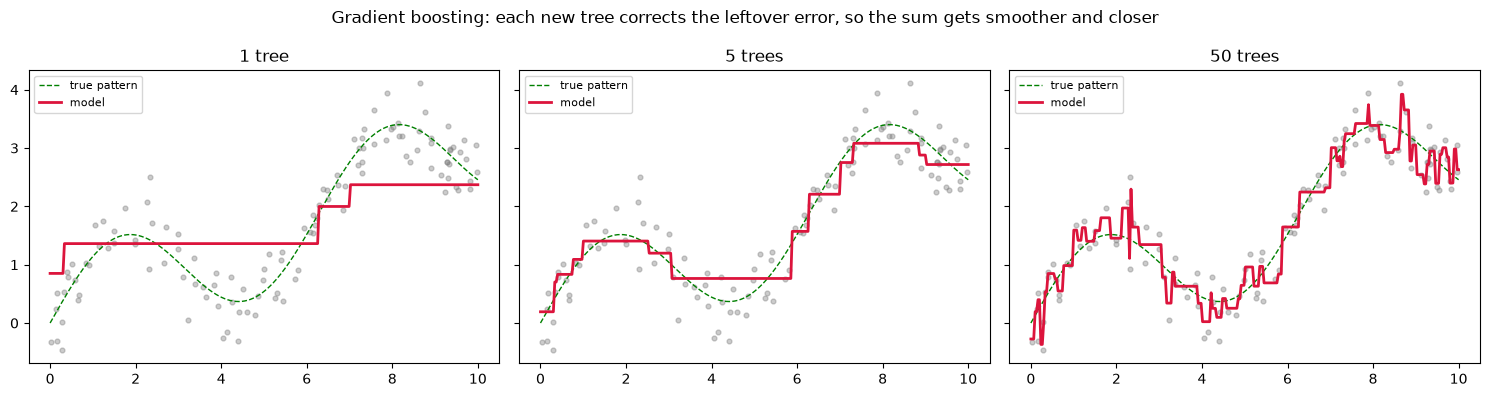

In [2]:
from sklearn.ensemble import GradientBoostingRegressor

rng = np.random.default_rng(0)
xx = np.linspace(0, 10, 300)
truth = np.sin(xx) + 0.3 * xx
xt = rng.uniform(0, 10, 120)
yt = np.sin(xt) + 0.3 * xt + rng.normal(0, 0.35, 120)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, n in zip(ax, [1, 5, 50]):
    g = GradientBoostingRegressor(n_estimators=n, max_depth=2, learning_rate=0.5, random_state=0)
    g.fit(xt.reshape(-1, 1), yt)
    a.scatter(xt, yt, s=12, alpha=.4, color="grey")
    a.plot(xx, truth, "g--", lw=1, label="true pattern")
    a.plot(xx, g.predict(xx.reshape(-1, 1)), color="crimson", lw=2, label="model")
    a.set_title(f"{n} tree{'s' if n > 1 else ''}"); a.legend(fontsize=8)
fig.suptitle("Gradient boosting: each new tree corrects the leftover error, so the sum gets smoother and closer")
plt.tight_layout()

**Read it left to right:** one shallow tree is a crude staircase. Five trees start
tracing the shape. Fifty trees hug the true pattern without chasing every noisy
point (that restraint comes from the small `learning_rate` and shallow trees). The
real model does this in ~80 dimensions instead of one, but the idea is identical.

## 2. An honest first score: spatial cross-validation

**Cross-validation** estimates how well the model does on listings it has never
seen: split the rows into 5 groups, train on 4, score on the 1 held out, rotate,
average. The textbook version splits *randomly*. Here, that cheats.

> ### Deeper: why random splitting cheats, and how blocking fixes it
>
> Two Airbnbs on the same street are almost the same listing - same area, same
> transport, often the same host. Shuffle randomly and one lands in *training*
> while its near-twin lands in *test*. The model effectively studies for its own
> exam, and the score comes out too good.
>
> The fix is **blocked / spatial cross-validation**: lay a ~2 km grid over London
> and split by **grid cell**. A whole cell is either training or test in a given
> fold, never both. Now "test" always means "an area the model hasn't memorised".
>
> Roberts et al. (2017), *Ecography* - the standard reference.

The map below shows the actual split: each colour is one of the 5 folds, and
you can see they're contiguous blocks, not a random speckle.

> **Thought process.** I ran plain random `KFold` first, out of habit, and got a
> nice number. Then I remembered the scatter plot from notebook 01: listings sit
> right on top of each other. A random split puts near-duplicates on both sides
> of the train/test line, so the score is inflated. Switching to blocked folds is
> the fix, and section 4 measures how much the habit was costing.

design matrix: (59450, 81)


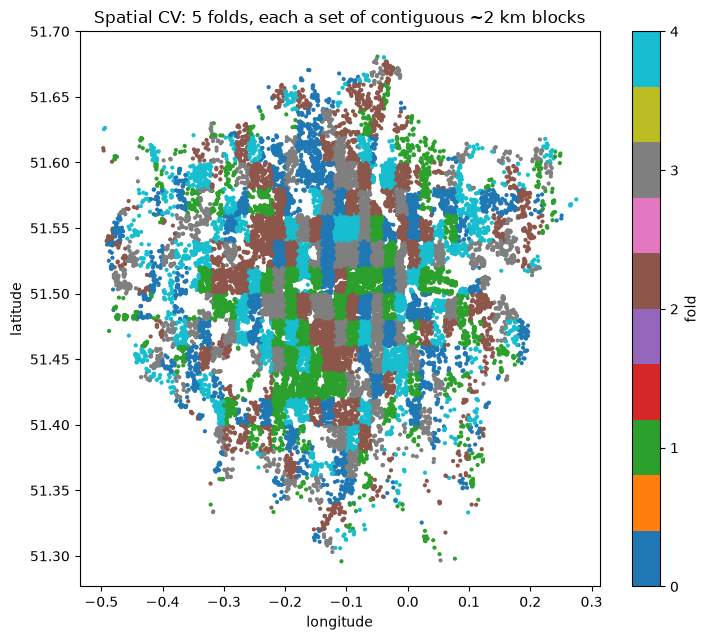

In [3]:
enc = M.fit_encoder(frame, groups["categorical"])
X = M.build_design_matrix(frame, groups, enc)      # one-hot cats + raw numerics, dense, named
print("design matrix:", X.shape)

spatial = M.spatial_block_folds(frame["latitude"].to_numpy(),
                                frame["longitude"].to_numpy(), n_splits=5, seed=0)

# visualise which fold each listing landed in
fold_id = np.empty(len(frame), dtype=int)
for k, (_, te) in enumerate(spatial):
    fold_id[te] = k
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc = ax.scatter(frame["longitude"], frame["latitude"], c=fold_id, cmap="tab10", s=4)
ax.set_title("Spatial CV: 5 folds, each a set of contiguous ~2 km blocks")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.colorbar(sc, label="fold", ticks=range(5))
plt.tight_layout()

In [4]:
def oof_predict(make, folds):
    '''Out-of-fold predictions: every row predicted by a model that never saw it.
    `make` is a zero-arg factory so each fold gets a fresh, unfitted model.'''
    pred = np.full(len(y), np.nan)
    for tr, te in folds:
        m = make()
        m.fit(X.iloc[tr], y[tr])
        pred[te] = m.predict(X.iloc[te])
    return pred

pred_spatial = oof_predict(lambda: M.make_model(), spatial)
pd.Series(M.evaluate(y, pred_spatial)).round(4)

MAE_gbp         55.7483
RMSE_gbp        92.8997
MdAPE            0.1948
within_15pct     0.3995
MAE_log          0.2548
R2_log           0.7783
dtype: float64

### How to read those metrics

| metric | what it means |
|---|---|
| `MAE_gbp` | average miss, in **pounds per night** |
| `RMSE_gbp` | like MAE but squares errors first - inflated when the model badly misses a few |
| `MdAPE` | the **median** listing is off by this **percentage** |
| `within_15pct` | share of listings priced to within ±15% of the truth |
| `R2_log` | fraction of the variation in log-price explained (1 = perfect, 0 = no better than the mean) |

**What we see:** under honest spatial CV the model sits at **£-MAE ≈ £56, median %
error ≈ 19%, R²(log) ≈ 0.78** - well past the notebook-01 baseline (£-MAE ≈ 90 /
R² ≈ 0.49) and the notebook-02 model (£72 / 0.65). So the listing's own attributes
and amenities add real, separable signal. *(This £56 is with the review columns;
section 6 has the smaller cold-start number the app ships.)*

## 3. Is the model worth its complexity? (vs a linear baseline)

A gradient-boosted forest is a lot more machinery than a straight line. It should
have to *earn* that. So we run **ridge regression** - linear regression with a
penalty that stops coefficients blowing up - on the same features, same folds.

> ### Deeper: what ridge needs that the tree didn't
>
> A linear model is sensitive to missing values and to features on wildly
> different scales (`dist_center_m` in the thousands vs a 0/1 flag). So its
> pipeline has two extra steps the tree never needed: `SimpleImputer` (fill every
> gap) and `StandardScaler` (recentre each column to mean 0, spread 1). `RidgeCV`
> then tries a range of penalty strengths and keeps the best.
>
> Ridge and the bias-variance reason for the penalty: ISLR §6.2.1.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

def make_linear():
    return make_pipeline(
        SimpleImputer(strategy="median"),        # linear models can't take NaN
        StandardScaler(),                        # put every column on a common scale
        RidgeCV(alphas=np.logspace(-2, 3, 20)),  # try 20 penalty strengths, keep the best
    )

pred_linear = oof_predict(make_linear, spatial)
pd.DataFrame({
    "linear (ridge)":         M.evaluate(y, pred_linear),
    "gradient-boosted trees": M.evaluate(y, pred_spatial),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
linear (ridge),64.1077,0.2236,0.3519,0.7204
gradient-boosted trees,55.7483,0.1948,0.3995,0.7783


**What we see.**

| model | £-MAE | median % err | within ±15% | R²(log) |
|---|---|---|---|---|
| ridge (linear) | 64.1 | 22.4% | 35.2% | 0.720 |
| gradient-boosted trees | **55.7** | **19.5%** | **40.0%** | **0.778** |

The tree model beats ridge by about **£8/night and +0.06 R²**.

> ### Deeper: why trees win here specifically
>
> Price depends on **interactions**: an extra bedroom is worth more in Kensington
> than in Barnet; being far from a Tube matters less if you're already central. A
> linear model assumes each feature's effect is a fixed amount, independent of the
> others. Trees carve the data into regions and fit each separately, so they pick
> up those "it depends" effects for free. **Verdict: the complexity is earned.**

## 4. How much would a *random* split have flattered us?

Same model, same data - only the split changes (random 5-fold instead of the 2 km
blocks). The gap is the size of the "studying your own twin" effect.

In [6]:
from sklearn.model_selection import KFold
random_folds = list(KFold(n_splits=5, shuffle=True, random_state=0).split(X))
pred_random = oof_predict(lambda: M.make_model(), random_folds)

pd.DataFrame({
    "random CV (optimistic)": M.evaluate(y, pred_random),
    "spatial CV (honest)":    M.evaluate(y, pred_spatial),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
random CV (optimistic),53.0396,0.1848,0.4174,0.7968
spatial CV (honest),55.7483,0.1948,0.3995,0.7783


**What we see.**

| | £-MAE | median % err | R²(log) |
|---|---|---|---|
| random 5-fold CV | 53.0 | 18.5% | 0.797 |
| spatial block CV | 55.7 | 19.5% | 0.778 |

Random CV is optimistic by about **£2.7/night and 0.02 R²**.

> ### Deeper: a small gap is itself a finding
>
> The gap is real but small - spatial autocorrelation in this data is **mild at the
> neighbourhood scale**. London Airbnbs aren't clustered tightly enough for a 2 km
> block to leak much. That's genuine information, not a disappointment. On data with
> *strong* grouping (repeated users, a few hospitals, daily time series) the same
> experiment can move the metric 10× as much. From here we quote the **spatial**
> number.

## 5. A light tune

The defaults in `londonrent.model.DEFAULT_PARAMS` are reasonable but not tuned. We
run a small **randomised search** over the main knobs.

> ### Deeper: the four knobs, in plain terms
>
> - `learning_rate` - how big a correction each new tree may make. Smaller =
>   steadier; too big overshoots.
> - `max_leaf_nodes` - how bendy each individual tree can be.
> - `min_samples_leaf` - refuse to make a decision for a group smaller than this
>   (a guard against fitting to a handful of quirky listings).
> - `l2_regularization` - a general "keep it simple" penalty.
>
> We search with fast 3-fold *random* CV (just to *rank* settings cheaply), then
> re-check the winner under honest spatial CV.
>
> Bergstra & Bengio (2012), "Random Search for Hyper-Parameter Optimization" - 
> random sampling beats an exhaustive grid for the same compute budget.

> **Thought process.** I expected tuning to buy a point or two of R-squared, and
> planned a paragraph explaining the winning settings. It bought nothing. The
> tempting move is to re-roll seeds until tuning looks like it helped. I decided
> the honest write-up is 'it did not move, and here is why', which is also more
> useful to a reader.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

search = RandomizedSearchCV(
    M.make_model({"max_iter": 400}),                    # cap trees during the search for speed
    param_distributions={
        "learning_rate":     loguniform(0.02, 0.2),
        "max_leaf_nodes":    randint(15, 63),
        "min_samples_leaf":  randint(20, 120),
        "l2_regularization": loguniform(0.01, 10),
    },
    n_iter=12, cv=3, scoring="neg_mean_absolute_error",
    random_state=0, n_jobs=-1,
)
search.fit(X, y)
print("best params:", search.best_params_)

pred_tuned = oof_predict(lambda: M.make_model(search.best_params_), spatial)
pd.DataFrame({
    "default params": M.evaluate(y, pred_spatial),
    "tuned params":   M.evaluate(y, pred_tuned),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

best params: {'l2_regularization': np.float64(6.823493012435792), 'learning_rate': np.float64(0.06650867830801169), 'max_leaf_nodes': 38, 'min_samples_leaf': 55}


,MAE_gbp,MdAPE,within_15pct,R2_log
default params,55.7483,0.1948,0.3995,0.7783
tuned params,55.6006,0.1944,0.4013,0.7787


**What we see.** The search landed on
`learning_rate≈0.07, max_leaf_nodes=38, min_samples_leaf=55, l2≈6.8`. Under spatial
CV the tuned model (£-MAE 55.6, R² 0.779) is **indistinguishable from the defaults**
(£-MAE 55.7, R² 0.778) - the difference is well inside noise.

**Honest conclusion:** tuning didn't help. `HistGradientBoostingRegressor` with
early stopping already regularises itself. We keep the tuned params for the final
model (they cost nothing) but the *gain is ~zero* - worth saying plainly rather
than dressing up as a win.

## 6. What are the review / host features worth? (and a caveat)

`build_model_frame(with_reviews=False)` drops the review and host columns. That's
the model you'd use to price a listing that **doesn't exist yet** - no reviews, no
history.

> ### Deeper: the target-leakage caveat
>
> Reviews and scores are generated *after* a listing goes live, and partly reflect
> how it's been priced and how in-demand it is. Using them to "predict" price is a
> little **circular** - a mild form of **target leakage** (a feature that wouldn't
> honestly be available at prediction time). Fine for a listing running a year;
> wrong for a brand new one. So we report both, and the app ships the **cold-start
> (no-reviews)** model.
>
> "Target leakage" / "data snooping": the Kaggle *Intermediate ML* course;
> Géron Ch. 2.

> **Thought process.** I wanted the review columns in the model because they
> clearly help the score. Then I thought about *when* the app would run: on a
> listing that does not exist yet. A brand-new listing has no reviews, and review
> counts partly reflect how it has been priced anyway. So the shipped model drops
> them, and this section measures what that costs.

In [8]:
frame_cold, groups_cold = build_model_frame(with_reviews=False)
y_cold = frame_cold["log_price"].to_numpy()
enc_cold = M.fit_encoder(frame_cold, groups_cold["categorical"])
Xc = M.build_design_matrix(frame_cold, groups_cold, enc_cold)
spatial_cold = M.spatial_block_folds(frame_cold["latitude"].to_numpy(),
                                     frame_cold["longitude"].to_numpy(), n_splits=5, seed=0)

def oof_predict_X(make, folds, Xmat, yv):
    pred = np.full(len(yv), np.nan)
    for tr, te in folds:
        m = make(); m.fit(Xmat.iloc[tr], yv[tr]); pred[te] = m.predict(Xmat.iloc[te])
    return pred

pred_cold = oof_predict_X(lambda: M.make_model(search.best_params_), spatial_cold, Xc, y_cold)
pd.DataFrame({
    "with reviews/host (track record)": M.evaluate(y, pred_tuned),
    "no reviews/host (cold start)":     M.evaluate(y_cold, pred_cold),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
with reviews/host (track record),55.6006,0.1944,0.4013,0.7787
no reviews/host (cold start),62.0646,0.2234,0.3518,0.7163


**What we see.**

| | £-MAE | median % err | R²(log) |
|---|---|---|---|
| with reviews/host (track record) | 55.6 | 19.4% | 0.779 |
| **no reviews/host (cold start)** | **62.1** | **22.3%** | **0.716** |

Losing the review and host columns costs about **£6.5/night and 0.06 R²** - the
measurable value of a track record. The cold-start model is still far better than
the baseline and is the honest tool for a brand-new listing, so **that's the one we
save**.

## 7. Lock a final model and test it once

Everything above used cross-validation for *choosing*. Now the thing you only get
to do once: hold out whole areas of London, train on the rest, evaluate a single
time. This is the number that goes on a slide. We use the **cold-start** feature
set (the app model).

> ### Deeper: why "once"?
>
> Every time you look at a test score and then change something, a little of that
> test set leaks into your choices. Do it enough and your "test" is really another
> validation set. So we spend the held-out fold exactly once, after all decisions
> are locked. Watch for: does the model **under-predict the expensive tail**
> (common with a logged target), and are residuals **mixed evenly in space**?

In [9]:
test_tr, test_te = spatial_cold[0]            # fold 0's held-out cells = the test set
final = M.make_model(search.best_params_)
final.fit(Xc.iloc[test_tr], y_cold[test_tr])
pred_te = final.predict(Xc.iloc[test_te])
test_metrics = M.evaluate(y_cold[test_te], pred_te)
pd.Series(test_metrics).round(4)

MAE_gbp         59.8165
RMSE_gbp        96.5045
MdAPE            0.2185
within_15pct     0.3541
MAE_log          0.2824
R2_log           0.7205
dtype: float64

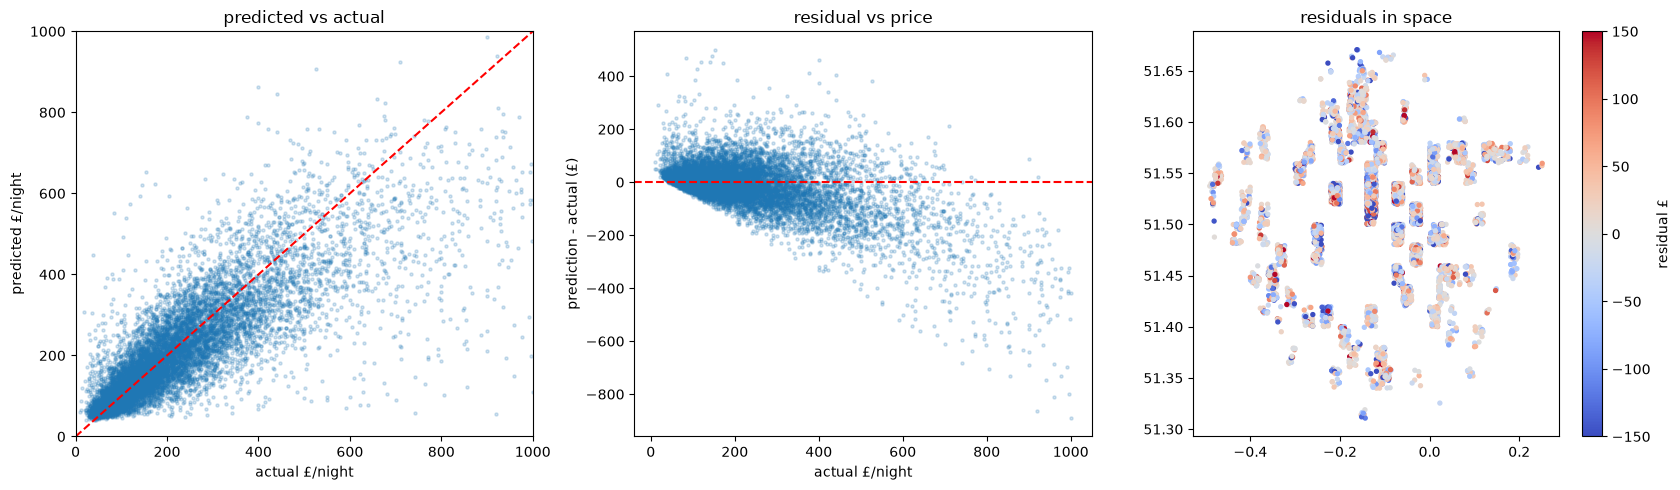

In [10]:
gbp_true, gbp_pred = np.exp(y_cold[test_te]), np.exp(pred_te)   # back to £ for readable plots
resid = gbp_pred - gbp_true                                     # +ve = model over-priced

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].scatter(gbp_true, gbp_pred, s=5, alpha=.2)
lim = [0, 1000]; ax[0].plot(lim, lim, "r--")
ax[0].set(xlim=lim, ylim=lim, xlabel="actual £/night", ylabel="predicted £/night", title="predicted vs actual")
ax[1].scatter(gbp_true, resid, s=5, alpha=.2); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="actual £/night", ylabel="prediction - actual (£)", title="residual vs price")
sc = ax[2].scatter(frame_cold["longitude"].iloc[test_te], frame_cold["latitude"].iloc[test_te],
                   c=np.clip(resid, -150, 150), cmap="coolwarm", s=8)
fig.colorbar(sc, ax=ax[2], label="residual £"); ax[2].set_title("residuals in space")
plt.tight_layout()

**What we see.** On the held-out cells the cold-start model scores **£-MAE ≈ £60 -
median % error ≈ 22%, within ±15% ≈ 35%, R²(log) ≈ 0.72** - a touch worse than
the cross-validated figure (normal - one fold is noisier, and fold 0's areas may be
a little harder). *Predicted vs actual* hugs the diagonal up to ~£300 then fans out
and sits **below** the line - the model **under-prices the expensive tail**, the
expected effect of a logged target plus a thin luxury sample. *Residuals in space*
are fairly well mixed.

## 8. SHAP - why did the model say that?

A single accuracy number doesn't tell a host *why* their listing came out at £140.
**SHAP** does.

> ### Deeper: what a SHAP value is
>
> Start from the model's **average prediction** - what you'd guess knowing nothing
> about a specific listing. Reveal this listing's features one at a time and watch
> the prediction move. A feature's **SHAP value** is its share of the total journey
> from that average to the final number: "+£30 Camden, -£15 no dishwasher, +£8
> close to a station...". The pieces **add up exactly** to the prediction.
>
> Those shares are **Shapley values** from cooperative game theory (Lloyd Shapley,
> 1953): "how should a team split a payout, given each member's average marginal
> contribution". Lundberg & Lee (2017) applied them to ML - features are the
> players, the prediction is the payout - with an **exact fast algorithm for tree
> models** (`shap.TreeExplainer`), which is why we can run it on thousands of rows.
>
> Lundberg & Lee (2017), NeurIPS; Molnar's IML book, SHAP chapter.

/Users/kst/london-rent-reality-check/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


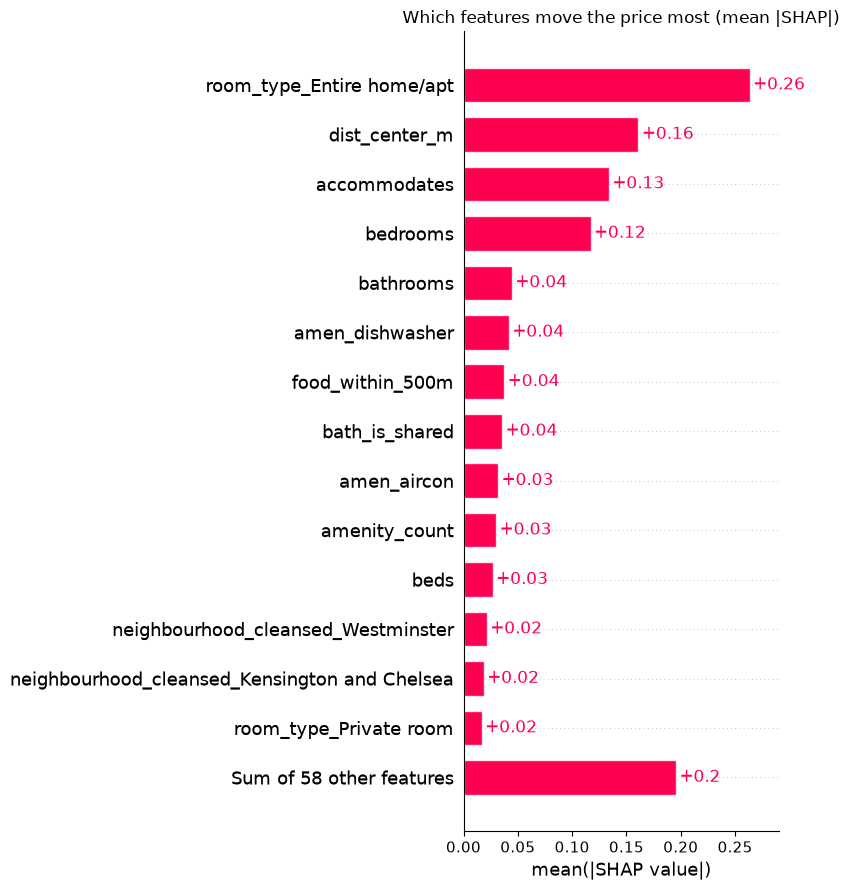

In [11]:
import shap

explainer = shap.TreeExplainer(final)
sample = Xc.iloc[test_te].sample(min(3000, len(test_te)), random_state=0)
sv = explainer(sample)

shap.plots.bar(sv, max_display=15, show=False)
plt.title("Which features move the price most (mean |SHAP|)")
plt.tight_layout(); plt.show()

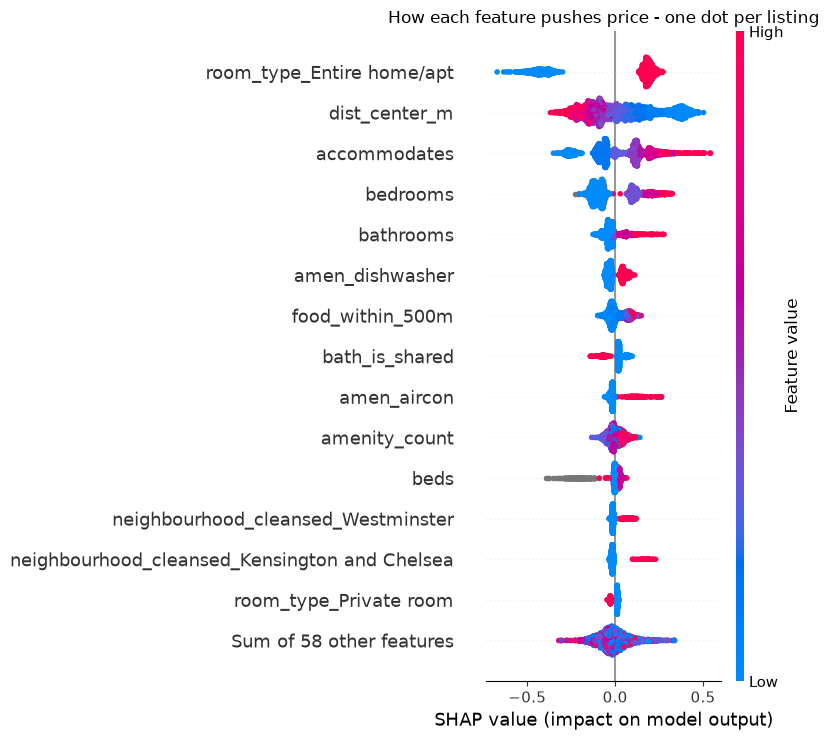

In [12]:
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("How each feature pushes price - one dot per listing")
plt.tight_layout(); plt.show()

**How to read the beeswarm:** one row per feature (most important on top), one dot
per listing. **Right of centre** = that feature pushed *that listing's* price up;
left = down. **Colour** = the feature's value (red high, blue low). A row where red
sits right and blue sits left reads "more of this → higher price".

**What we see.** `accommodates`, the `dist_center_m` / `dist_station_m` location block, `bathrooms`, and a few borough dummies (Westminster, Kensington and Chelsea push up) dominate - signs all match notebooks 01-02. Premium amenities each nudge price the expected way but are second-order next to size and location.


=== cheapest ===  actual £10  |  Entire home/apt, rental_unit, sleeps 1, Barnet


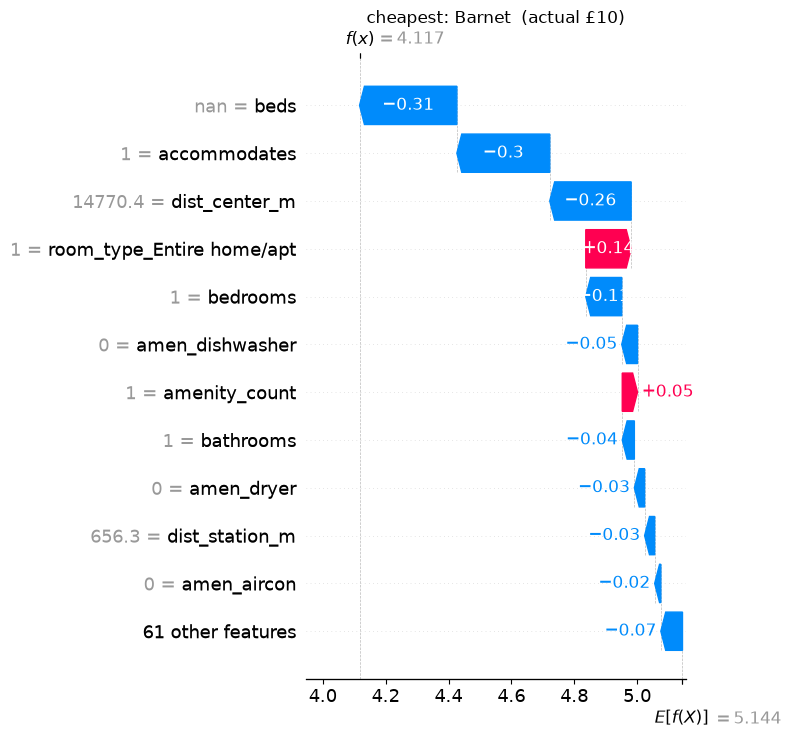


=== priciest ===  actual £1000  |  Entire home/apt, rental_unit, sleeps 1, Hounslow


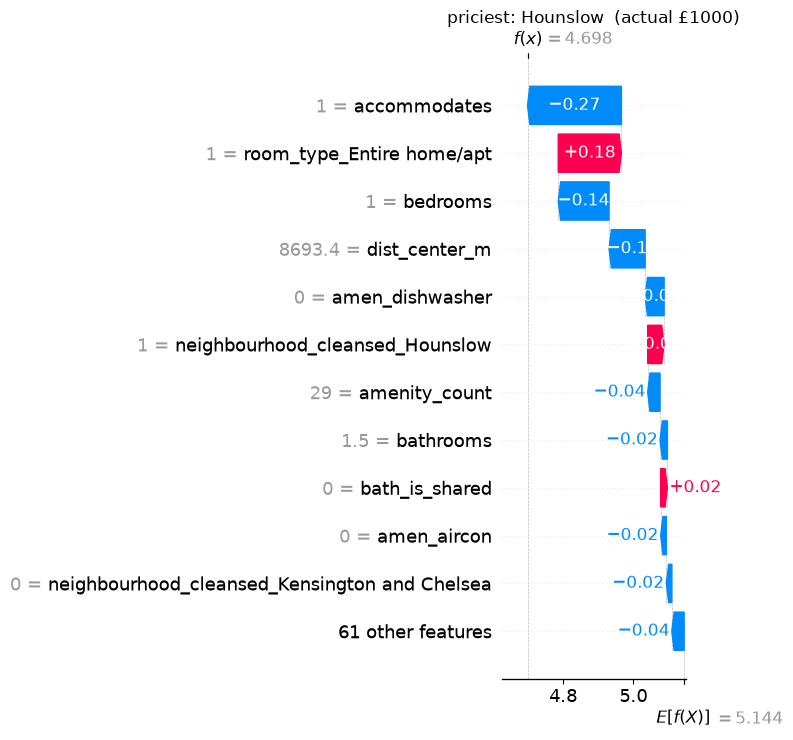


=== model disagrees most ===  actual £1000  |  Entire home/apt, rental_unit, sleeps 1, Hounslow


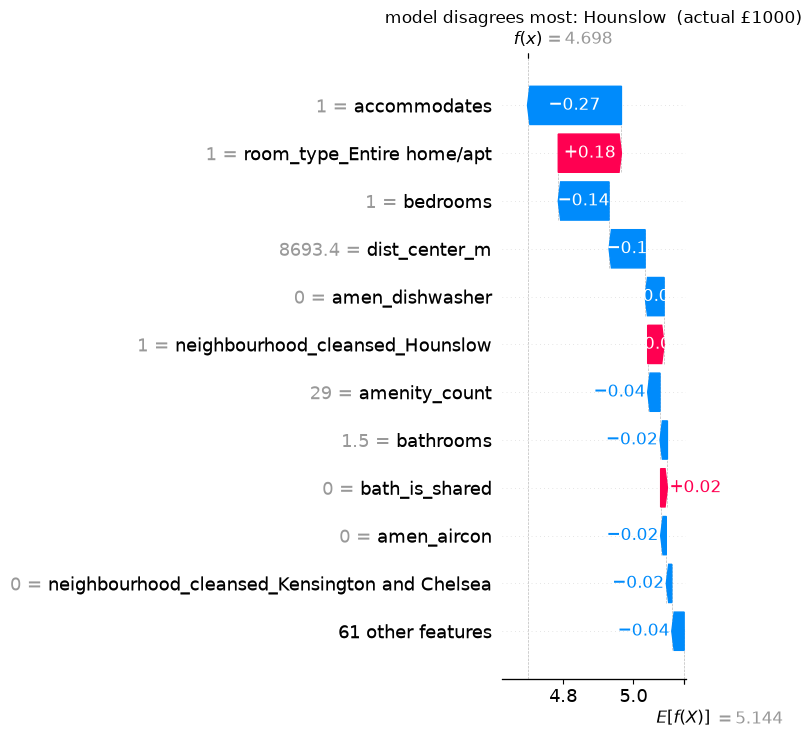

In [13]:
# Local explanations: three individual listings - a cheap one, a dear one, and the
# one the model got most wrong (largest |residual|), because that's where you learn
# what the model leans on when it fails.
te_idx = np.array(test_te)
order = np.argsort(gbp_true)
picks = {
    "cheapest": te_idx[order[0]],
    "priciest": te_idx[order[-1]],
    "model disagrees most": te_idx[int(np.argmax(np.abs(resid)))],
}
for label, ridx in picks.items():
    row = frame_cold.loc[ridx]
    actual = np.exp(row["log_price"])
    print(f"\n=== {label} ===  actual £{actual:.0f}  |  "
          f"{row['room_type']}, {row['property_class']}, "
          f"sleeps {row['accommodates']:.0f}, {row['neighbourhood_cleansed']}")
    one = explainer(Xc.loc[[ridx]])
    shap.plots.waterfall(one[0], max_display=12, show=False)
    plt.title(f"{label}: {row['neighbourhood_cleansed']}  (actual £{actual:.0f})")
    plt.tight_layout(); plt.show()

**What we see.** Each waterfall starts at the model's baseline `E[f(x)]` (the
average log-price) and stacks feature contributions to reach the prediction. The
*cheapest* is a £10 studio in Barnet - the model climbs well above £10, i.e. it
thinks £10 isn't a real rate (it almost certainly isn't). The *priciest* and the
*disagrees-most* listing are the **same** row: a £1,000/night whole flat that
*sleeps 1*, in Hounslow (near Heathrow). Dropping hotel-class listings (§1) killed
the old £1000 hotel-room artefacts, but the **£1,000 price cap itself** still
produces edge cases - here a one-person flat priced like a luxury home. A v3 would
lower the cap or model the tail separately.

## 9. Does the model treat some boroughs much worse than others?

A "fair price" tool shouldn't be far more wrong in some areas than others.

> ### Deeper: disaggregated evaluation
>
> A single headline metric can hide that a model works for the majority and badly
> for a minority. Breaking the score down by subgroup - here borough - is the core
> idea behind **model cards** (Mitchell et al., 2019) and Google's "disaggregated
> evaluation" guidance.

In [14]:
by_boro = (pd.DataFrame({
        "borough": frame_cold["neighbourhood_cleansed"].iloc[test_te].to_numpy(),
        "ape": np.abs(gbp_pred - gbp_true) / gbp_true,           # absolute % error per listing
    })
    .groupby("borough")["ape"].agg(["median", "count"])
    .sort_values("median", ascending=False))
by_boro.round(3).head(12)

,median,count
borough,,
Merton,0.299,185
Wandsworth,0.291,16
Enfield,0.266,74
Sutton,0.265,92
Ealing,0.263,50
Brent,0.250,555
Havering,0.248,49
Barking and Dagenham,0.248,70
Bexley,0.246,82


**What we see.** The worst-predicted boroughs are **Merton (30% median error,
n=185), Enfield (27%, n=74), Sutton (27%, n=92)** and other **outer-London** areas
 - mostly a *data-volume* problem (little to learn those areas from). One genuine
flag: **Brent (25%, n=555)** is well-sampled yet middling, so it would be the first
place to dig in a v3. Reported, not hidden.

## 9b. How sure is the model? A rough prediction band

Every prediction so far is a single number. A host would also want to know how
tight that number is: "about £140" is very different depending on whether the
model means £130 to £150 or £90 to £220.

### The plain idea

Train two more copies of the same model, but instead of predicting the *middle*
price, one predicts the **10th percentile** and one the **90th percentile** of the
price for a listing like this. The gap between them is a rough 10-to-90 band: for a
well-behaved model, about 80% of real prices should fall inside it.

`HistGradientBoostingRegressor` does this with one setting, `loss="quantile"`.
(`londonrent.model.make_quantile_model` wraps it.)

### How honest is this band?

Not fully. Quantile regression can be miscalibrated, so we **check**: what fraction
of held-out actual prices actually land inside the band? If that number is near
80%, the band is roughly trustworthy. If it is well off, the band is the wrong
width. The proper fix, **conformal prediction**, adjusts the band to hit a target
coverage exactly; I have not done that here, so treat this as a guide, not a
guarantee.

> **Thought process.** I nearly shipped point predictions only. It felt dishonest
> to hand someone "£146" with no sense of the spread, especially since the
> held-out error analysis already showed the model is much less sure at the top of
> the price range. Quantile loss is a small change; checking the coverage is the
> part that keeps it honest.
>
> Where this comes from: quantile regression is in the scikit-learn "Quantile
> regression" user guide and the `HistGradientBoostingRegressor` docs. Conformal
> prediction (the calibrated version) is from Vovk et al.; a readable intro is the
> `MAPIE` library's documentation.

In [15]:
# out-of-fold 10th and 90th percentile predictions, using the same spatial folds
lo = np.full(len(y_cold), np.nan)
hi = np.full(len(y_cold), np.nan)
for tr, te in spatial_cold:
    mlo = M.make_quantile_model(0.1); mlo.fit(Xc.iloc[tr], y_cold[tr])
    mhi = M.make_quantile_model(0.9); mhi.fit(Xc.iloc[tr], y_cold[tr])
    lo[te] = mlo.predict(Xc.iloc[te])
    hi[te] = mhi.predict(Xc.iloc[te])

# quantile models are fit independently, so occasionally lo > hi; sort each pair
lo_gbp, hi_gbp = np.sort(np.c_[np.exp(lo), np.exp(hi)], axis=1).T
actual = np.exp(y_cold)

inside = (actual >= lo_gbp) & (actual <= hi_gbp)
print(f"empirical coverage of the 10-to-90 band: {inside.mean():.1%}  (target ~80%)")
print(f"median band width: £{np.median(hi_gbp - lo_gbp):.0f}")
print(f"median band width as a share of the prediction: "
      f"{np.median((hi_gbp - lo_gbp) / np.exp(pred_cold)):.0%}")

empirical coverage of the 10-to-90 band: 74.9%  (target ~80%)
median band width: £142
median band width as a share of the prediction: 79%


In [16]:
# 40 held-out listings, sorted by predicted price: band as a vertical line, actual as a dot
te = np.array(spatial_cold[0][1])
samp = te[np.argsort(np.exp(pred_cold)[te])][:: max(1, len(te) // 40)][:40]
order = np.argsort(np.exp(pred_cold)[samp])
s = samp[order]

fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(len(s))
ax.vlines(xs, lo_gbp[s], hi_gbp[s], color="#94a3b8", lw=3, label="10-to-90 band")
ax.plot(xs, np.exp(pred_cold)[s], "o", color="#2563eb", ms=4, label="model prediction")
inside_s = (actual[s] >= lo_gbp[s]) & (actual[s] <= hi_gbp[s])
ax.plot(xs[inside_s], actual[s][inside_s], "o", color="#16a34a", ms=5, label="actual (in band)")
ax.plot(xs[~inside_s], actual[s][~inside_s], "x", color="#dc2626", ms=7, label="actual (outside)")
ax.set(xlabel="held-out listings, sorted by predicted price", ylabel="£/night",
       title="The band widens for pricier listings, and most actuals fall inside it")
ax.legend(); plt.tight_layout()

**What we see.** The 10-to-90 band covers **74.9%** of held-out actual prices,
against a target of 80%. So the band is slightly **too narrow**: quantile
regression fit this way is not perfectly calibrated, and a proper fix (conformal
prediction) would widen it to hit 80% exactly. As a rough guide it is fine, and
the plot shows the useful part clearly: the band **widens for pricier listings**,
which matches the held-out error analysis, and roughly three in four actuals fall
inside it. The median band is about £140 wide, or 79% of the prediction, which is a
blunt but honest signal that nightly short-let prices are genuinely hard to pin to
a tight number.

The two quantile models are saved alongside the main model so the app can show the
band as "about £X, likely £low to £high", with a note that it is approximate.

## 10. Save the model for the app

In [17]:
from londonrent.config import PROJECT_ROOT

# Evaluating is done, so refit the cold-start model on ALL the data (more data =
# a slightly better final model) and save everything the app needs in one file:
# the fitted encoder, the model, the feature-group lists, and the honest held-out
# metrics (so the app can quote its own accuracy).
app_model = M.make_model(search.best_params_)
app_model.fit(Xc, y_cold)

# the 10th / 90th percentile models for the prediction band
q_models = {q: M.make_quantile_model(q).fit(Xc, y_cold) for q in (0.1, 0.9)}
M.save_bundle(
    PROJECT_ROOT / "models" / "price_model.joblib",
    encoder=enc_cold, model=app_model, groups=groups_cold, metrics=test_metrics,
    quantile_models=q_models,
)
print("saved models/price_model.joblib")

saved models/price_model.joblib


## Conclusions

**In plain terms.** Starting from "just guess the local average" (£-MAE ≈ 90 / R² ≈
0.49), the finished model gets a typical London listing's nightly price to within
about **£60, or ~22%**, on areas of the city it never trained on - and it can show
*which* features drove any single prediction. It's weakest on the expensive tail
(it under-prices luxury listings, and the £1,000 price cap still spawns edge cases)
and in a few thinly-sampled outer boroughs. It deliberately excludes review scores
so it can price brand-new listings - that costs ~£6.5/night of accuracy, measured. Each prediction also comes with a rough 10-to-90 band (empirical coverage 75%, slightly narrow), which widens for pricier listings.

**For the reader with ML background.** `HistGradientBoostingRegressor` on ~59k
listings (v2 scope: no hotel-class), `log(price)` target, native NaN handling (no
imputation on the tree path). Spatial block CV (Roberts et al. 2017); random CV
overstated R² by ~0.02 here, and the small size of that gap is itself informative.
Beats a `RidgeCV` baseline by ~£8 MAE / +0.06 R² → interactions matter.
`RandomizedSearchCV` produced no meaningful gain, reported as-is. Track-record vs
cold-start feature sets compared with the target-leakage reasoning explicit; the
app ships cold-start (£-MAE ≈ 60 / R² ≈ 0.72 on held-out). Explanations via exact
TreeSHAP; error-by-borough as a fairness check.

### Week-3 exit checklist
- [x] Honest spatial-CV metrics recorded (£-MAE ≈ 56 / R² ≈ 0.78 with reviews; 62 / 0.72 cold-start)
- [x] Beats ridge baseline by ~£8 MAE / +0.06 R² - complexity justified
- [x] Random-vs-spatial CV gap quantified (~£2.7 MAE / 0.02 R² - mild here)
- [x] Tuning done - no meaningful gain, kept the tuned params and said so
- [x] Cold-start costs ~£6.5 MAE vs track-record; app ships the cold-start model
- [x] Held-out test done once (£-MAE ≈ 60 / R² ≈ 0.72); under-prices the luxury tail
- [x] SHAP global + 3 local explanations interpreted; worst miss is a £1000-cap edge case
- [x] Error-by-borough check done (worst = sparse outer boroughs; Brent flagged)
- [x] Rough prediction band added (quantile loss); coverage checked (75% vs 80% target)
- [x] `models/price_model.joblib` saved (main model + 0.1/0.9 quantile models)